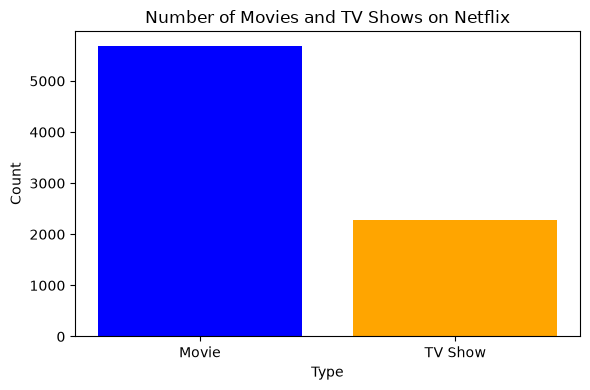

In [2]:
# step 1: import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

# step 2: load the data
df =pd.read_csv('netflix_titles.csv')

# step 3: clean the data
df = df.dropna(subset=['type','release_year','rating','country','duration'])

# how many movies and TV shows ? making a bar chart
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['blue','orange'])
plt.title('Number of Movies and TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png', dpi=300)
plt.show()



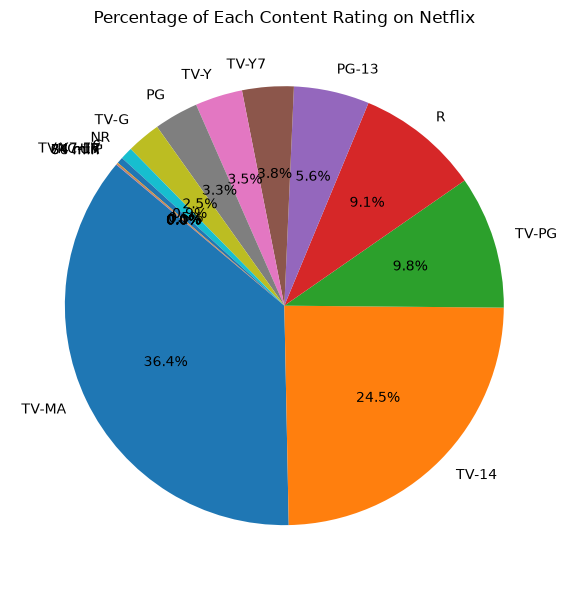

In [ ]:
#what is perccentage of each content rating (pg,r,tv-MA) making a pie chart


import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv('netflix_titles.csv')
rating_counts=df['rating'].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', startangle=140,)
plt.title('Percentage of Each Content Rating on Netflix')
plt.tight_layout()
plt.savefig('content_rating_percentage.png', dpi=300)
plt.show()



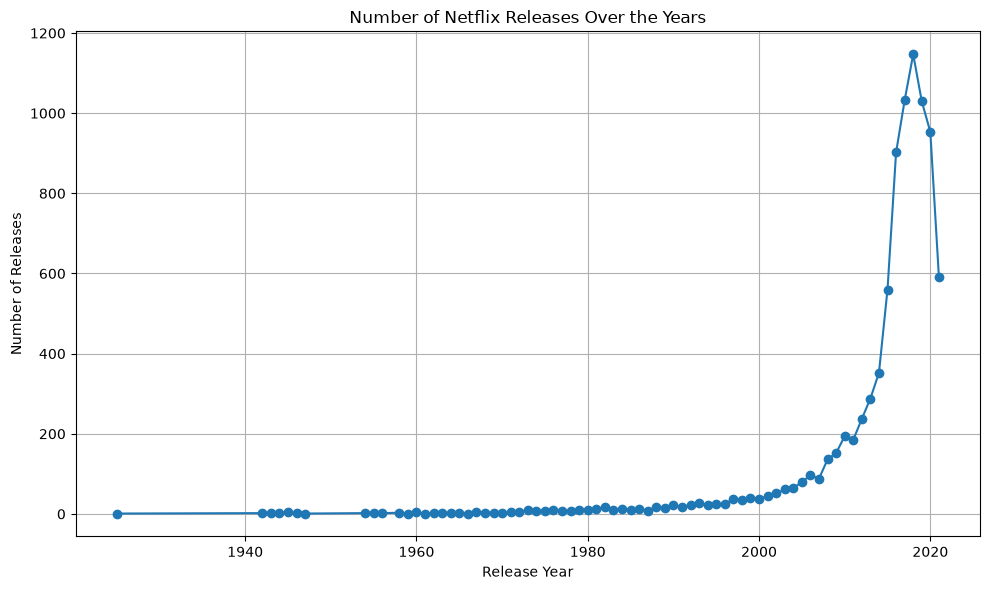

In [9]:
#how has the number of release over the year making a line chart
 
import pandas as pd
import matplotlib.pyplot as plt
df =pd.read_csv('netflix_titles.csv')
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.plot(release_counts.index,release_counts.values, marker='o')
plt.title('Number of Netflix Releases Over the Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Releases')
plt.grid(True)
plt.tight_layout()

plt.show()


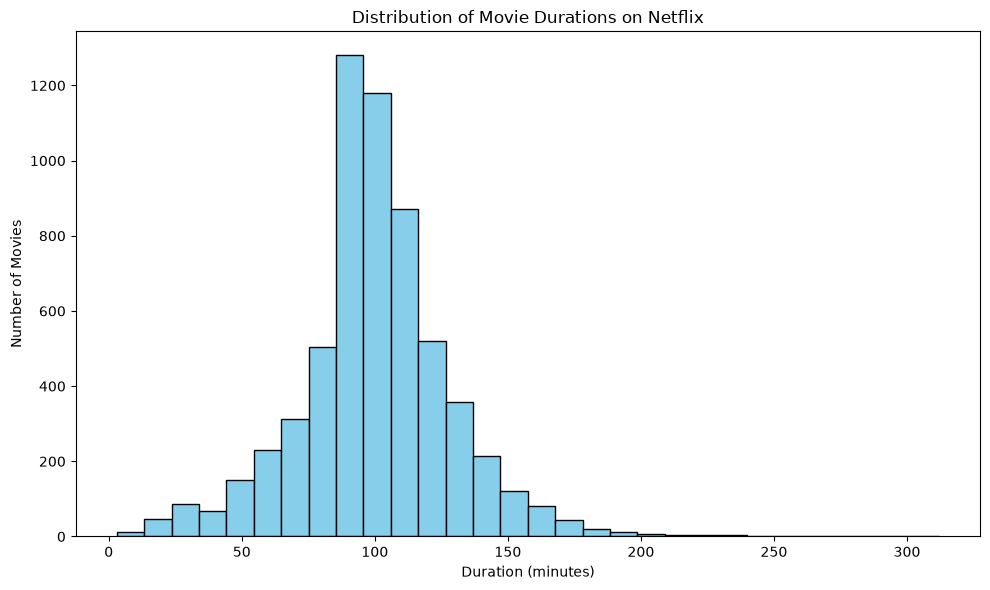

In [ ]:
# what is the distribution of movie durations on Netflix? making a histogram

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')

movie_df = df[df['type'] == 'Movie'].copy()
movie_df['duration_int'] = movie_df['duration'].str.replace('min', '', regex=False).str.strip()
movie_df['duration_int'] = pd.to_numeric(movie_df['duration_int'], errors='coerce')
movie_df = movie_df.dropna(subset=['duration_int'])
plt.figure(figsize=(10, 6))
plt.hist(movie_df['duration_int'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()

plt.savefig('movie_duration_distribution.png', dpi=300)

plt.show()




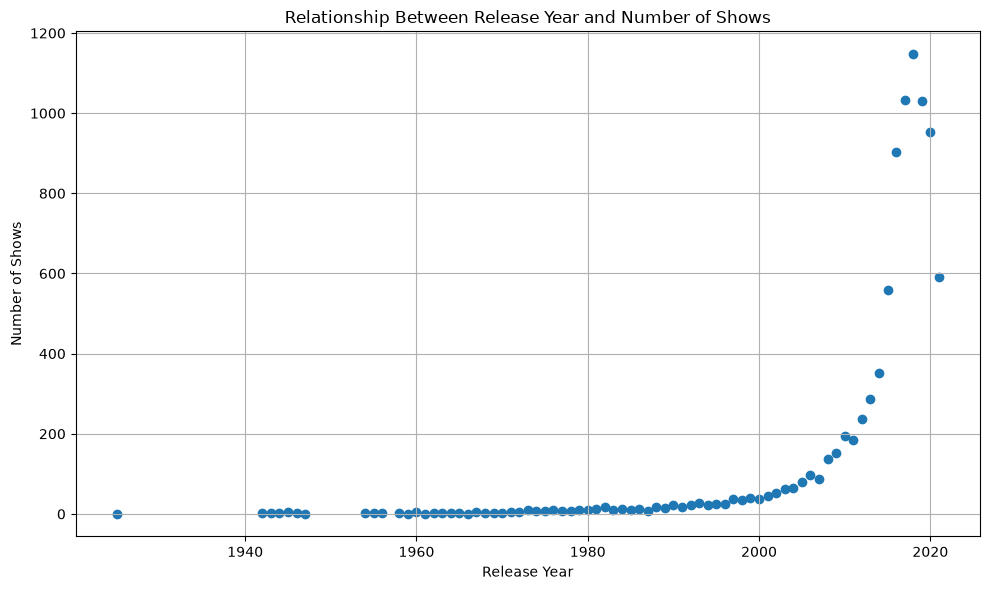

In [18]:
#relationship between release year and number of shows making a scatter plot

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')
release_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
plt.scatter(release_counts.index, release_counts.values)
plt.title('Relationship Between Release Year and Number of Shows')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows')
plt.grid(True)
plt.tight_layout()

plt.savefig('release_year_vs_number_of_shows.png', dpi=300)

plt.show()




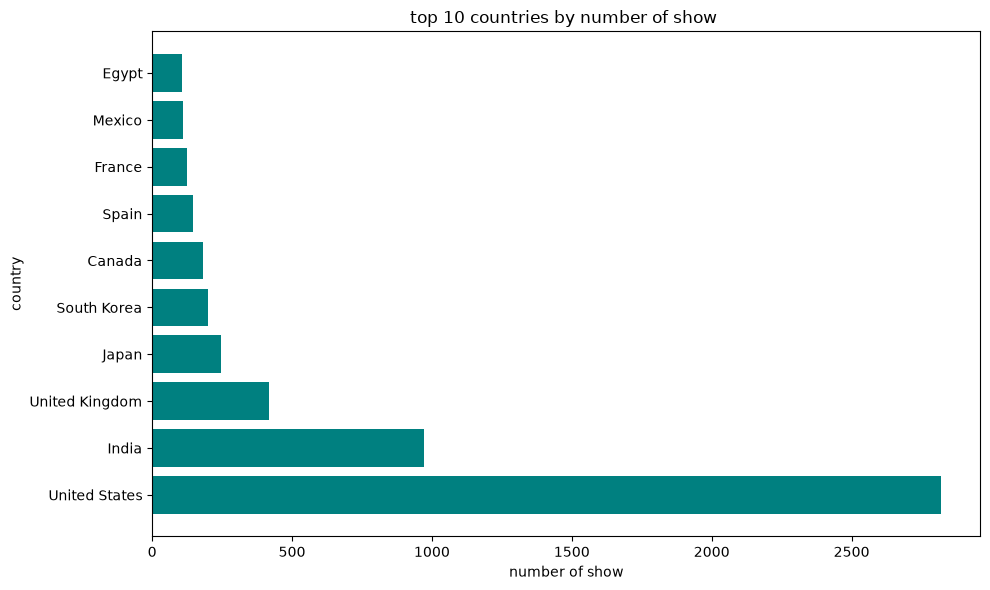

In [ ]:
#top 10 countries with the highest number of show

import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('netflix_titles.csv')

country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.barh(country_counts.index, country_counts.values, color='teal')
plt.title ('top 10 countries by number of show ')
plt.xlabel('number of show')
plt.ylabel('country')
plt.tight_layout()
plt.show()

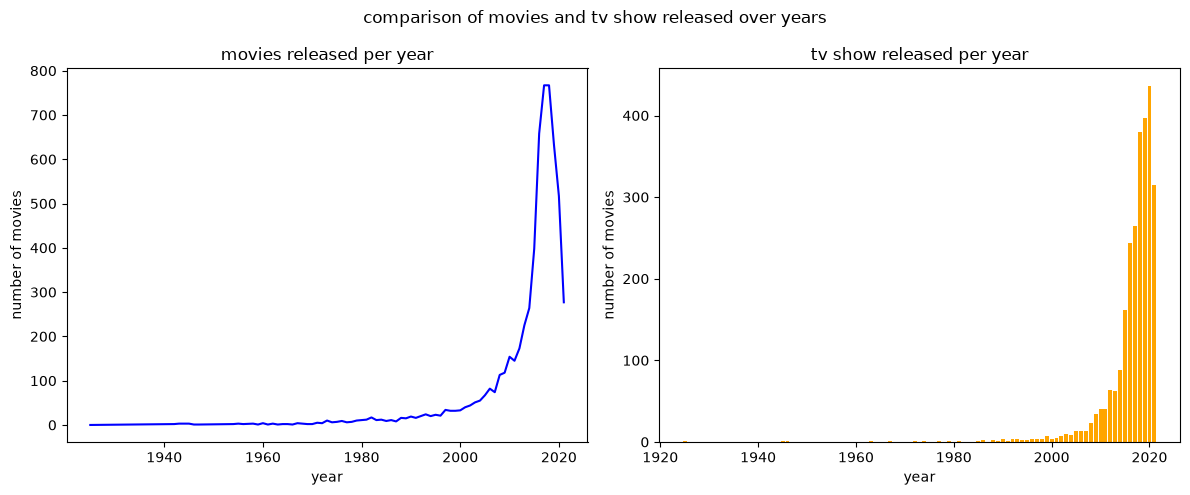

In [ ]:
#compare multiple plots together(e.g movies vs tv show by year)


import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('netflix_titles.csv')
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig, ax = plt.subplots(1,2,figsize=(12,5))

#first subplot 
ax[0].plot(content_by_year.index, content_by_year['Movie'], color='blue')
ax[0].set_title('movies released per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('number of movies')

#second subplot 
ax[1].bar(content_by_year.index, content_by_year['TV Show'], color='orange')
ax[1].set_title('tv show released per year')
ax[1].set_xlabel('year')
ax[1].set_ylabel('number of movies')

fig.suptitle('comparison of movies and tv show released over years')

plt.tight_layout()
plt.show()